# 06 — Evaluation

**Threat Incident Intelligence Platform**

This notebook consolidates evaluation across all ML/NLP tasks:

| Task | Metrics |
|------|---------|
| Urgency classification | Accuracy, macro/weighted F1, precision, recall, confusion matrix |
| Priority classification | Macro/weighted F1, confusion matrix |
| Semantic search | Qualitative relevance + sample Precision@k |
| NLP preprocessing | Coverage, vocab stats |
| Artifacts | Presence & loadability check |


In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai


In [10]:
import json
import time
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

from src.config import settings, validate_config
from src.db import ping_database, close_connection, count_incidents, find_incidents, find_incident_by_id
from src.preprocessing import clean_text, build_tfidf_corpus, tokenize_and_clean, get_stopwords
from src.models.loaders import (
    get_models_dir,
    load_joblib_model,
    load_embeddings,
    load_vectorizer,
    load_model_metadata_file,
    list_available_models,
)
from src.models.predictors import predict_urgency, predict_priority, find_similar_incidents
from src.utils import setup_logging, timer, safe_float, truncate_text

logger = setup_logging("INFO", name="evaluation")
validate_config()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

MODELS_DIR = get_models_dir()
RANDOM_STATE = 42
print(f"Models directory: {MODELS_DIR}")
print("Setup complete")

[config] MongoDB URI loaded (db=threat_intelligence)
[config] Collections: ['incidents', 'incident_features', 'predictions', 'models_metadata']
Models directory: C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models
Setup complete


In [11]:
expected = [
    "tfidf_vectorizer.joblib",
    "urgency_classifier.joblib",
    "priority_model.joblib",
    "priority_meta.joblib",
    "embeddings.npy",
    "cluster_ids.npy",
    "metadata.json",
]

available = list_available_models()
print("Artifacts on disk:")
for name in expected:
    path = MODELS_DIR / name
    status = "OK" if path.exists() else "MISSING"
    size = f"{path.stat().st_size / 1e6:.2f} MB" if path.exists() else "—"
    print(f"  [{status:7s}] {name:35s} {size}")

print(f"\nAll files in models/: {available}")

Artifacts on disk:
  [OK     ] tfidf_vectorizer.joblib             0.41 MB
  [OK     ] urgency_classifier.joblib           0.08 MB
  [OK     ] priority_model.joblib               1.80 MB
  [OK     ] priority_meta.joblib                0.00 MB
  [OK     ] embeddings.npy                      29.50 MB
  [OK     ] cluster_ids.npy                     0.21 MB
  [OK     ] metadata.json                       0.00 MB

All files in models/: ['cluster_ids.npy', 'embeddings.npy', 'metadata.json', 'priority_meta.joblib', 'priority_model.joblib', 'tfidf_cluster_ids.npy', 'tfidf_vectorizer.joblib', 'urgency_classifier.joblib']


In [12]:
meta = load_model_metadata_file()
if meta:
    print("Training metadata:")
    print(json.dumps(meta, indent=2))
else:
    print("No metadata.json found — run 05_ml_training.ipynb first for full metrics.")

Training metadata:
{
  "trained_at": "2026-10-06T08:24:53.926258Z",
  "urgency_classifier": {
    "file": "urgency_classifier.joblib",
    "algorithm": "linear_svm",
    "metrics": {
      "model_name": "Linear SVM (urgency)",
      "accuracy": 0.9947903099765564,
      "macro_f1": 0.4986941760250718,
      "weighted_f1": 0.9937510931471215,
      "classes": [
        "low",
        "medium"
      ]
    },
    "features": "tfidf",
    "vectorizer": "tfidf_vectorizer.joblib"
  },
  "priority_model": {
    "file": "priority_model.joblib",
    "algorithm": "random_forest",
    "metrics": {
      "model_name": "Random Forest (priority)",
      "accuracy": 0.9989586045300703,
      "macro_f1": 0.9664869398514259,
      "weighted_f1": 0.9989931305457099,
      "classes": [
        "critical",
        "high",
        "low",
        "medium"
      ]
    },
    "feature_columns": [
      "threat_score",
      "severity_score",
      "credibility_score",
      "source_count",
      "article_coun

In [13]:
if not ping_database():
    raise RuntimeError("Cannot reach MongoDB.")

total = count_incidents()
print(f"Incidents in MongoDB: {total:,}")
if total == 0:
    raise RuntimeError("No data. Run 01_data_ingestion.ipynb first.")

Incidents in MongoDB: 19,204


In [14]:
with timer("Loading incidents"):
    docs = find_incidents(
        projection={
            "_id": 0,
            "cluster_id": 1,
            "title": 1,
            "summary": 1,
            "title_clean": 1,
            "summary_clean": 1,
            "keywords": 1,
            "urgency_level": 1,
            "threat_score": 1,
            "severity_score": 1,
            "credibility_score": 1,
            "source_count": 1,
            "article_count": 1,
        }
    )

df = pd.DataFrame(docs)
print(f"DataFrame shape: {df.shape}")

[timer] Loading incidents: 1.82s
DataFrame shape: (19204, 12)


In [15]:
vectorizer = None
urgency_model = None
priority_model = None
priority_meta = None
embeddings = None
cluster_ids = None

try:
    vectorizer = load_vectorizer()
    print("Loaded tfidf_vectorizer")
except FileNotFoundError as e:
    print(f"SKIP vectorizer: {e}")

try:
    urgency_model = load_joblib_model("urgency_classifier")
    print("Loaded urgency_classifier")
except FileNotFoundError as e:
    print(f"SKIP urgency model: {e}")

try:
    priority_model = load_joblib_model("priority_model")
    priority_meta = joblib.load(MODELS_DIR / "priority_meta.joblib")
    print("Loaded priority_model + meta")
except Exception as e:
    print(f"SKIP priority model: {e}")

try:
    embeddings, cluster_ids = load_embeddings()
    print(f"Loaded embeddings {embeddings.shape}")
except FileNotFoundError as e:
    print(f"SKIP embeddings: {e}")

Loaded tfidf_vectorizer
Loaded urgency_classifier
Loaded priority_model + meta
Loaded embeddings (19204, 384)


In [16]:
def combine_text(row: pd.Series) -> str:
    title = row.get("title_clean") or clean_text(str(row.get("title") or ""))
    summary = row.get("summary_clean") or clean_text(str(row.get("summary") or ""))
    keywords = row.get("keywords") or []
    kw = " ".join(str(k) for k in keywords if k)
    return " ".join(p for p in [title, summary, kw] if p)

df["text_combined"] = df.apply(combine_text, axis=1)

n_total = len(df)
n_empty = (df["text_combined"].str.len() == 0).sum()
n_missing_title = df["title"].isna().sum() if "title" in df.columns else 0
n_missing_summary = df["summary"].isna().sum() if "summary" in df.columns else 0

sample_tokens = [tokenize_and_clean(t) for t in df["text_combined"].head(500)]
avg_tokens = np.mean([len(t) for t in sample_tokens]) if sample_tokens else 0

print("NLP Coverage")
print(f"  Documents            : {n_total:,}")
print(f"  Empty combined text  : {n_empty:,} ({100*n_empty/max(n_total,1):.2f}%)")
print(f"  Missing title        : {n_missing_title:,}")
print(f"  Missing summary      : {n_missing_summary:,}")
print(f"  Avg tokens (sample)  : {avg_tokens:.1f}")
print(f"  Stopword list size   : {len(get_stopwords())}")

nlp_report = {
    "documents": n_total,
    "empty_text_pct": round(100 * n_empty / max(n_total, 1), 2),
    "avg_tokens_sample": round(float(avg_tokens), 1),
}

NLP Coverage
  Documents            : 19,204
  Empty combined text  : 0 (0.00%)
  Missing title        : 0
  Missing summary      : 0
  Avg tokens (sample)  : 96.1
  Stopword list size   : 198


URGENCY CLASSIFICATION
Test samples   : 3,839
Accuracy       : 0.9948
Macro F1       : 0.4987
Weighted F1    : 0.9938
Macro Precision: 0.4982
Macro Recall   : 0.4992

Classification Report:
              precision    recall  f1-score   support

         low       0.00      0.00      0.00        14
      medium       1.00      1.00      1.00      3825

    accuracy                           0.99      3839
   macro avg       0.50      0.50      0.50      3839
weighted avg       0.99      0.99      0.99      3839



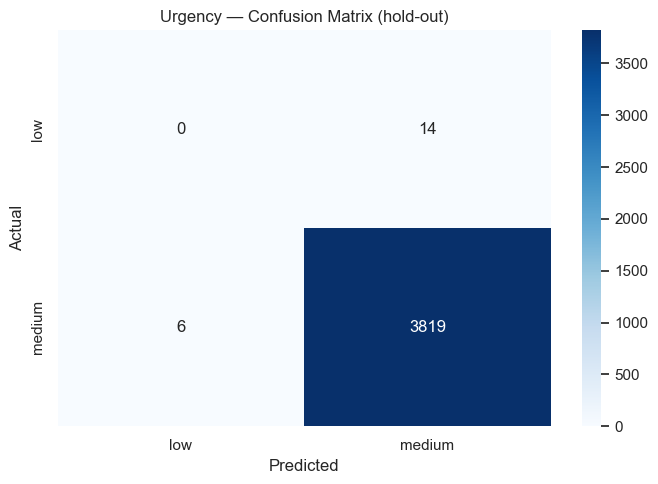

In [17]:
urgency_report = None

if urgency_model is None or vectorizer is None:
    print("Urgency model or vectorizer missing — skip evaluation.")
else:
    df["urgency"] = df["urgency_level"].fillna("unknown").astype(str).str.strip().str.lower()
    classes = list(urgency_model.classes_)
    mask = df["urgency"].isin(classes)
    df_u = df[mask].reset_index(drop=True)

    X = vectorizer.transform(df_u["text_combined"].tolist())
    y = df_u["urgency"].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    y_pred = urgency_model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro", zero_division=0)
    f1_wt = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    prec_macro = precision_score(y_te, y_pred, average="macro", zero_division=0)
    rec_macro = recall_score(y_te, y_pred, average="macro", zero_division=0)

    print("=" * 60)
    print("URGENCY CLASSIFICATION")
    print("=" * 60)
    print(f"Test samples   : {len(y_te):,}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro F1       : {f1_macro:.4f}")
    print(f"Weighted F1    : {f1_wt:.4f}")
    print(f"Macro Precision: {prec_macro:.4f}")
    print(f"Macro Recall   : {rec_macro:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    cm = confusion_matrix(y_te, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title("Urgency — Confusion Matrix (hold-out)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    urgency_report = {
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(f1_macro), 4),
        "weighted_f1": round(float(f1_wt), 4),
        "macro_precision": round(float(prec_macro), 4),
        "macro_recall": round(float(rec_macro), 4),
        "test_size": int(len(y_te)),
        "classes": classes,
    }

PRIORITY CLASSIFICATION
Features       : ['threat_score', 'severity_score', 'credibility_score', 'source_count', 'article_count']
Test samples   : 3,841
Accuracy       : 0.9990
Macro F1       : 0.9665
Weighted F1    : 0.9990

Classification Report:
              precision    recall  f1-score   support

    critical       1.00      1.00      1.00        20
        high       1.00      1.00      1.00      1024
         low       0.81      0.93      0.87        14
      medium       1.00      1.00      1.00      2783

    accuracy                           1.00      3841
   macro avg       0.95      0.98      0.97      3841
weighted avg       1.00      1.00      1.00      3841



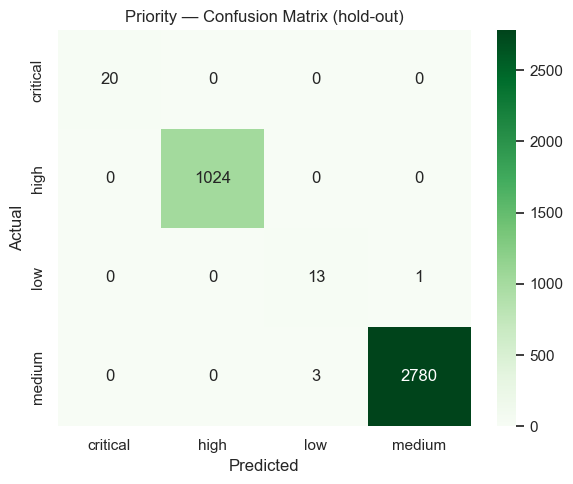

In [18]:
priority_report = None

if priority_model is None or priority_meta is None:
    print("Priority model missing — skip evaluation.")
else:
    def derive_priority(row: pd.Series) -> str:
        threat = safe_float(row.get("threat_score"), default=0.0)
        severity = safe_float(row.get("severity_score"), default=0.0)
        urgency = str(row.get("urgency_level") or "").lower()
        if threat >= 80 or urgency in ("critical",) or (urgency == "high" and severity >= 70):
            return "critical"
        if threat >= 60 or urgency == "high":
            return "high"
        if threat >= 35 or urgency == "medium":
            return "medium"
        return "low"

    df["priority"] = df.apply(derive_priority, axis=1)
    struct_cols = priority_meta.get("feature_columns", [
        "threat_score", "severity_score", "credibility_score",
        "source_count", "article_count",
    ])
    struct_cols = [c for c in struct_cols if c in df.columns]

    X_s = df[struct_cols].apply(pd.to_numeric, errors="coerce").fillna(0).values
    y_s = df["priority"].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_s, y_s, test_size=0.2, random_state=RANDOM_STATE, stratify=y_s
    )
    y_pred = priority_model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1_macro = f1_score(y_te, y_pred, average="macro", zero_division=0)
    f1_wt = f1_score(y_te, y_pred, average="weighted", zero_division=0)

    print("=" * 60)
    print("PRIORITY CLASSIFICATION")
    print("=" * 60)
    print(f"Features       : {struct_cols}")
    print(f"Test samples   : {len(y_te):,}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"Macro F1       : {f1_macro:.4f}")
    print(f"Weighted F1    : {f1_wt:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, zero_division=0))

    classes = list(priority_model.classes_)
    cm = confusion_matrix(y_te, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title("Priority — Confusion Matrix (hold-out)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    priority_report = {
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(f1_macro), 4),
        "weighted_f1": round(float(f1_wt), 4),
        "test_size": int(len(y_te)),
        "features": struct_cols,
        "classes": classes,
    }

In [19]:
search_report = None

if embeddings is None or cluster_ids is None:
    print("Embeddings missing — skip semantic search evaluation.")
else:
    n_check = min(200, len(embeddings))
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(embeddings), size=n_check, replace=False)

    self_rank1 = 0
    for idx in sample_idx:
        q = embeddings[idx]
        scores = embeddings @ q
        top = int(np.argmax(scores))
        if top == idx:
            self_rank1 += 1

    self_retrieval_acc = self_rank1 / n_check
    print(f"Self-retrieval @1 (n={n_check}): {self_retrieval_acc:.4f}")

    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer("all-MiniLM-L6-v2")

    queries = [
        "ransomware attack on hospitals",
        "zero-day CVE in VPN gateway",
        "phishing campaign targeting banks",
        "supply chain malware in software update",
        "DDoS botnet critical infrastructure",
    ]

    latencies = []
    print("\nQualitative semantic search (top-3):")
    for q in queries:
        t0 = time.perf_counter()
        hits = find_similar_incidents(
            q, top_k=3,
            embeddings=embeddings,
            cluster_ids=cluster_ids,
            sentence_model=st_model,
        )
        latencies.append(time.perf_counter() - t0)

        print(f"\n  Query: {q}")
        for h in hits:
            doc = find_incident_by_id(h["cluster_id"])
            title = truncate_text(str(doc.get("title") if doc else "?"), 65)
            print(f"    {h['score']:.3f}  {title}")

    avg_latency_ms = 1000 * np.mean(latencies)
    print(f"\nAvg query latency: {avg_latency_ms:.1f} ms")

    search_report = {
        "self_retrieval_at_1": round(float(self_retrieval_acc), 4),
        "n_self_check": n_check,
        "avg_latency_ms": round(float(avg_latency_ms), 1),
        "embedding_dim": int(embeddings.shape[1]),
        "n_documents": int(embeddings.shape[0]),
    }

Self-retrieval @1 (n=200): 1.0000


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resour



Qualitative semantic search (top-3):

  Query: ransomware attack on hospitals
    0.813  Ransomware Attacks Targeting Global Healthcare Institutions
    0.776  Ransomware Threats Impacting Healthcare Sector
    0.775  Ransomware Threats Surge in Healthcare Sector

  Query: zero-day CVE in VPN gateway
    0.490  Zero-Day Exploits Target Cisco ISE and Citrix Vulnerabilities
    0.478  China-Linked Hackers Exploit CVE-2025-20393 Zero-Day Vulnerabili…
    0.474  Critical GitLab Gateway Flaw CVE-2026-1868 Allows RCE

  Query: phishing campaign targeting banks
    0.779  New Wave of Phishing Targets German Bank Customers
    0.690  Chameleon SEO Poisoning Targets Bank Customers with Cloaked Phis…
    0.689  Phishing and Social Engineering Remain Major Threats in Cybersec…

  Query: supply chain malware in software update
    0.698  Open Source Malware Instances Increased by 73% in 2025
    0.694  eScan Antivirus Supply Chain Compromise Distributes Malware
    0.683  eScan Antivirus Comprom

In [21]:
if urgency_model is not None and vectorizer is not None and urgency_report is not None:
    # Recompute urgency hold-out split so we do NOT reuse X_te from the
    # priority section (which has only structured numeric features).
    df_err = df.copy()
    df_err["urgency"] = (
        df_err["urgency_level"].fillna("unknown").astype(str).str.strip().str.lower()
    )
    classes_u = list(urgency_model.classes_)
    mask_u = df_err["urgency"].isin(classes_u)
    df_u_err = df_err[mask_u].reset_index(drop=True)

    X_u_err = vectorizer.transform(df_u_err["text_combined"].tolist())
    y_u_err = df_u_err["urgency"].values

    _, X_te_u, _, y_te_u = train_test_split(
        X_u_err, y_u_err, test_size=0.2, random_state=RANDOM_STATE, stratify=y_u_err
    )

    y_pred_full = urgency_model.predict(X_te_u)
    errors = []
    for true, pred in zip(y_te_u, y_pred_full):
        if true != pred:
            errors.append((true, pred))

    err_df = pd.DataFrame(errors, columns=["actual", "predicted"])
    if len(err_df):
        print(f"Misclassified on hold-out: {len(err_df):,} / {len(y_te_u):,}")
        print("\nMost common error pairs (actual → predicted):")
        print(err_df.value_counts().head(10).to_string())
    else:
        print("No misclassifications on hold-out (unlikely — check data).")
else:
    print("Skip error analysis (model not loaded).")

Misclassified on hold-out: 20 / 3,839

Most common error pairs (actual → predicted):
actual  predicted
low     medium       14
medium  low           6


In [22]:
print("""
LIMITATIONS
-----------
1. Titles and summaries are model-generated and may contain errors.
2. ThreatCluster scores are editorial ranking signals, not a universal severity standard.
3. Priority labels are project-defined heuristics, not ground-truth analyst labels.
4. Semantic search has no gold similar-pair labels; evaluation is qualitative + self-retrieval.
5. Class imbalance in urgency levels can inflate accuracy relative to macro F1.
6. Dataset does not include raw indicators (IPs, hashes, domains) or full article text.

ETHICAL USE
-----------
- Defensive cybersecurity research, education, and analytics only.
- Do not present model predictions as verified facts.
- Do not use the system to target, harass, or profile victims.
""")


LIMITATIONS
-----------
1. Titles and summaries are model-generated and may contain errors.
2. ThreatCluster scores are editorial ranking signals, not a universal severity standard.
3. Priority labels are project-defined heuristics, not ground-truth analyst labels.
4. Semantic search has no gold similar-pair labels; evaluation is qualitative + self-retrieval.
5. Class imbalance in urgency levels can inflate accuracy relative to macro F1.
6. Dataset does not include raw indicators (IPs, hashes, domains) or full article text.

ETHICAL USE
-----------
- Defensive cybersecurity research, education, and analytics only.
- Do not present model predictions as verified facts.
- Do not use the system to target, harass, or profile victims.



In [24]:
final_report = {
    "evaluated_at": datetime.utcnow().isoformat() + "Z",
    "nlp_coverage": nlp_report,
    "urgency_classification": urgency_report,
    "priority_classification": priority_report,
    "semantic_search": search_report,
    "artifacts": available,
}

report_path = MODELS_DIR / "evaluation_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2, default=str)

print("=" * 60)
print("FINAL EVALUATION REPORT")
print("=" * 60)
print(json.dumps(final_report, indent=2, default=str))
print("=" * 60)
print(f"Saved → {report_path}")

FINAL EVALUATION REPORT
{
  "evaluated_at": "2026-10-06T09:17:11.980692Z",
  "nlp_coverage": {
    "documents": 19204,
    "empty_text_pct": 0.0,
    "avg_tokens_sample": 96.1
  },
  "urgency_classification": {
    "accuracy": 0.9948,
    "macro_f1": 0.4987,
    "weighted_f1": 0.9938,
    "macro_precision": 0.4982,
    "macro_recall": 0.4992,
    "test_size": 3839,
    "classes": [
      "low",
      "medium"
    ]
  },
  "priority_classification": {
    "accuracy": 0.999,
    "macro_f1": 0.9665,
    "weighted_f1": 0.999,
    "test_size": 3841,
    "features": [
      "threat_score",
      "severity_score",
      "credibility_score",
      "source_count",
      "article_count"
    ],
    "classes": [
      "critical",
      "high",
      "low",
      "medium"
    ]
  },
  "semantic_search": {
    "self_retrieval_at_1": 1.0,
    "n_self_check": 200,
    "avg_latency_ms": 196.1,
    "embedding_dim": 384,
    "n_documents": 19204
  },
  "artifacts": [
    "cluster_ids.npy",
    "embedding

C:\Users\hp\AppData\Local\Temp\ipykernel_19960\1349605713.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "evaluated_at": datetime.utcnow().isoformat() + "Z",


In [25]:
close_connection()
print("MongoDB connection closed.")

MongoDB connection closed.
